Copyright Tarter, Herasymov, Priebracha 2025

Finding minimal recurrence:

In [32]:
import pandas as pd 
import numpy as np 
import math 
import random as rd
import warnings
import time
import secrets 
warnings.filterwarnings('ignore')

def genRec(length): #generate the recurrence for the test case
    rec = ''
    for i in range(length):
        rec += f'{rd.randint(0,1)}'

    #or maybe try a buffer
    # rec = secrets.randbits(length)
    return rec

def genSeq(slength, rlength): #generate the full sequence for the test case
    seq = ''
    rec = genRec(rlength)
    for i in range(slength):
        seq += rec
    return seq, rec, 0, 0, 0, 0, 0, 0


def backTest(upper):
    out = pd.DataFrame(columns=['BitCount', 'sampleSize', 'Time'])

    for i in range(upper-1):
        digitLength = 10**(i+1)
        sampleSize = 100

        tests = pd.DataFrame(columns=['Test Case', 'Reccurence', 'Solution', 'Solution Length', 'True Length', 'Test Case Length', 'Works?', 'Time']) #initialize the dataframe
        for k in range(sampleSize): #generate the test cases
            tests.loc[k] = genSeq(4,digitLength)
        testList = tests['Test Case'].to_list() #send each test case to a list

        def decode(sequence, tests, l):
            n = len(sequence) #get length
            factors = []
            for j in range(int(n//2)): #find factors ### O(n)
                if n % (j+1) == 0:
                    factors += [n/(j+1)]
            options = {}
            for i in range(len(factors)-1,0,-1): ####O(log(n))
                rec = sequence[int(n - factors[i]):n] #isolate the recurrence
                trial = f'{rec}'*int(n//factors[i]) #concat to make the trial
                if trial == str(tests.loc[l,'Test Case']): #tests if the trial works
                    options.update({len(rec):rec})
            return options[min(options)]

        l = 0
        for sequence in testList:
            start = time.time()
            tests.loc[l,'Solution'] = decode(sequence,tests,l)
            end = time.time()
            tests.loc[l,'Time'] = round(end - start,8)#log time for complexity
            tests.loc[l,'Solution Length'] = len(str(tests.loc[l,'Solution']))
            tests.loc[l,'True Length'] = len(tests.loc[l,'Reccurence'])
            tests.loc[l,'Test Case Length'] = len(tests.loc[l,'Test Case'])
            if tests.loc[l,'Reccurence'] == tests.loc[l,'Solution']:
                tests.loc[l,'Works?'] = 1
            l += 1

        # display(tests)
        out.loc[i]=[digitLength, sampleSize, np.mean(tests['Time'])]
        print(f'Mean time for {10}^{i+1} bits and {sampleSize} samples is {np.mean(tests['Time'])}.')
    return out

out = backTest(8)
display(out)

Mean time for 10^1 bits and 100 samples is 0.00011994609999999999.
Mean time for 10^2 bits and 100 samples is 0.0005123424.
Mean time for 10^3 bits and 100 samples is 0.0012852408999999999.
Mean time for 10^4 bits and 100 samples is 0.0046289015.
Mean time for 10^5 bits and 100 samples is 0.026051263500000005.
Mean time for 10^6 bits and 100 samples is 0.6160119367.
Mean time for 10^7 bits and 100 samples is 6.126642093700002.


,BitCount,sampleSize,Time
0,10.0,100.0,0.000120
1,100.0,100.0,0.000512
2,1000.0,100.0,0.001285
3,10000.0,100.0,0.004629
4,100000.0,100.0,0.026051
5,1000000.0,100.0,0.616012
6,10000000.0,100.0,6.126642


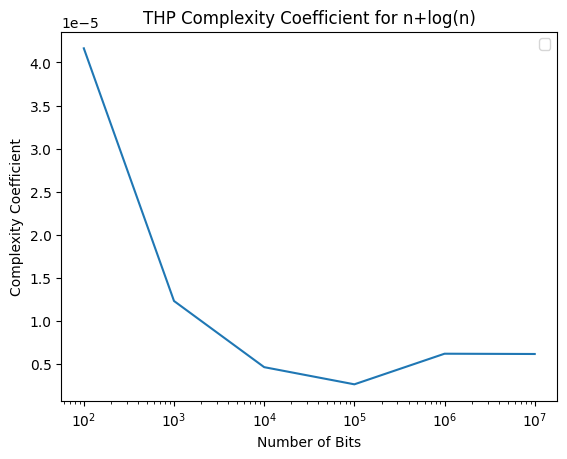

In [34]:
import matplotlib.pyplot as plt

def nLogn(n):
    df = pd.DataFrame(columns=['n','n+log(n)'])
    for i in range(1,n):
        df.loc[i] = [10**i, 10**i+math.log(10**i)]
    return df

nl_df = nLogn(7)

plt.figure
plt.title('THP Complexity Coefficient for n+log(n)')
plt.plot(out['BitCount'],out['Time']/nl_df['n+log(n)'])
plt.xscale('log')
plt.xlabel('Number of Bits')
plt.ylabel('Complexity Coefficient')
# plt.plot(nl_df['n'], nl_df['n+log(n)'], label = 'n+logn')
plt.legend()

,BitCount,Time
0,10.0,50.0
1,100.0,5000.0
2,1000.0,500000.0
3,10000.0,50000000.0
4,100000.0,5000000000.0
5,1000000.0,500000000000.0
6,10000000.0,50000000000000.0


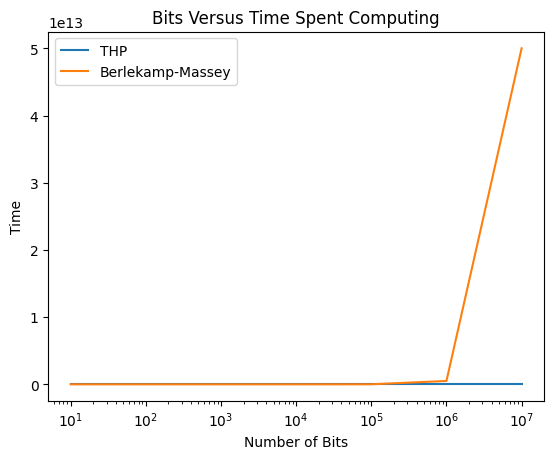

In [35]:
def bmcomp(out):
    bmout = pd.DataFrame(columns = ['BitCount','Time'])
    bmout['BitCount'] = out['BitCount']
    for bit in range(len(bmout['BitCount'])):
        bmout.loc[bit,'Time'] = (bmout.loc[bit,'BitCount']**2//4)*2
    return bmout

bmdf = bmcomp(out)
display(bmdf)

plt.figure
plt.title('Bits Versus Time Spent Computing')
plt.plot(out['BitCount'],out['Time'], label = 'THP')
plt.plot(bmdf['BitCount'], bmdf['Time'],label = 'Berlekamp-Massey')
plt.xscale('log')
plt.xlabel('Number of Bits')
plt.ylabel('Time')
plt.legend()